# Figure 4 — Crystal map (t-SNE)

Every object drawn as a 49-wedge 'crystal' glyph at its t-SNE coordinate. Needs the cached layout: `python scripts/build_cache.py --tsne` (or compute inline below).

In [1]:
# Make the things_spose package importable whether this runs from the repo
# root or notebooks/ (jupyter lab vs papermill/nbconvert set different cwds).
import sys, pathlib
for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_c / "things_spose").is_dir():
        sys.path.insert(0, str(_c)); break

import matplotlib.pyplot as plt
from things_spose.core import backend
from things_spose.data import dataio
print(backend.describe())
ds = dataio.load_dataset()
SAVE = False  # set True to export SVGs next to this notebook

device=cpu (kind=cpu), num_workers=8, similarity_backend=numba


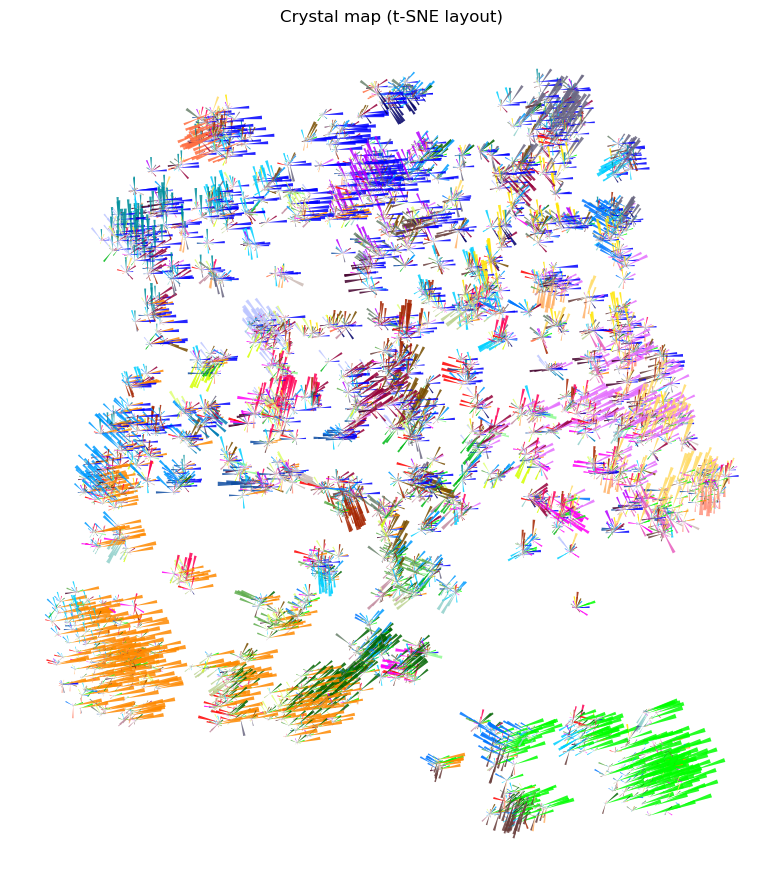

In [2]:
from things_spose.analysis import tsne, viz
from things_spose.core import artifacts
try:
    layout = artifacts.load_tsne_layout()
except FileNotFoundError:
    print('No cached layout; computing (slow) ...')
    layout = tsne.crystal_layout(ds.dissim)
fig = viz.fig4_crystal_map(ds, layout, save_path='fig4.svg' if SAVE else None)
plt.show()